#**Notebook 2: EDA RCA Semantica**

Objetivo: Ingestar los datos balanceados, inyectar el texto profundo de los errores (simulando Loghub/Software Observability) y enmascarar entidades sensibles mediante expresiones regulares (NLP).

##**Celda 1: Importación de librerías para PLN**

In [1]:
# Importamos pandas para la manipulación de los datos tabulares provenientes del Notebook 1.
import pandas as pd
# Importamos 're' (Expresiones Regulares) para la limpieza estructurada de texto.
import re
# Importamos numpy para el manejo de condicionales vectorizados.
import numpy as np

# Configuramos visualización de pandas para texto largo (evitamos cortes en el log message).
pd.set_option('display.max_colwidth', None)

##**Celda 2: Carga e Ingesta del Checkpoint**

In [2]:
from google.colab import files
import os
import pandas as pd

archivo_entrada = 'dataset_prevencion_limpio.csv'

# Validamos si el archivo está en la sesión actual
if not os.path.exists(archivo_entrada):
    print(f"Por favor, sube el archivo '{archivo_entrada}' generado en el Notebook 1:")
    uploaded = files.upload()

try:
    # Cargamos el dataset limpio
    df_rca = pd.read_csv(archivo_entrada)
    print(f"\nDataset cargado correctamente. Total de registros: {len(df_rca)}")
except FileNotFoundError:
    print(f"Error: Aún no se encuentra '{archivo_entrada}'.")

Por favor, sube el archivo 'dataset_prevencion_limpio.csv' generado en el Notebook 1:


Saving dataset_prevencion_limpio.csv to dataset_prevencion_limpio.csv

Dataset cargado correctamente. Total de registros: 8558


##**Celda 3: Inyección Semántica (El Enriquecimiento)**

In [3]:
import numpy as np

def inyectar_semantica(fila):
    # Extraemos las variables basadas en tu diccionario de datos real
    codigo = fila['http_status_code']
    endpoint = fila['URL']  # Esta la creamos en el Notebook 1
    latencia = fila['end_to_end_latency_ms'] # Usamos la latencia real del dataset
    usuario = fila['user_id'] # Usamos el ID de usuario real

    # Lógica de inyección condicional basada en reglas de negocio AIOps
    if codigo == 200:
        return f"[INFO] Transaction successful for endpoint {endpoint}. Latency: {latencia}ms."

    elif codigo == 500:
        return f"[ERROR] FATAL EXCEPTION in {endpoint}: java.lang.NullPointerException at payment.processor.validate()."

    elif codigo in [502, 503]:
        return f"[CRITICAL] Service Unavailable at {endpoint}. Backend core_billing_db is not responding."

    elif codigo == 504:
        return f"[WARN] Connection timed out after {latencia}ms waiting for external gateway visa_endpoint at {endpoint}."

    elif codigo == 429:
        return f"[WARN] Rate limit exceeded for user_id={usuario}. Dropping request at {endpoint}."

    elif codigo in [401, 403]:
        return f"[SECURITY] Unauthorized access attempt by user_id={usuario}. Invalid JWT signature for endpoint {endpoint}."

    else:
        return f"[UNKNOWN] Unhandled HTTP status {codigo} at {endpoint}."

# Aplicamos la función fila por fila
df_rca['Log_Message_Raw'] = df_rca.apply(inyectar_semantica, axis=1)

print("Ejemplo de inyección semántica exitosa:")
display(df_rca[['http_status_code', 'Log_Message_Raw']].sample(20))

Ejemplo de inyección semántica exitosa:


,http_status_code,Log_Message_Raw
1246,200,[INFO] Transaction successful for endpoint /api/pagos/pse. Latency: 4552.0909ms.
3616,200,[INFO] Transaction successful for endpoint /auth/token_gateway. Latency: 540.7417ms.
7826,403,[SECURITY] Unauthorized access attempt by user_id=396. Invalid JWT signature for endpoint /api/facturacion/procesar_tdc.
2189,500,[ERROR] FATAL EXCEPTION in /api/facturacion/procesar_tdc: java.lang.NullPointerException at payment.processor.validate().
1727,504,[WARN] Connection timed out after 69.3406ms waiting for external gateway visa_endpoint at /api/pagos/pse.
1527,401,[SECURITY] Unauthorized access attempt by user_id=453. Invalid JWT signature for endpoint /auth/token_gateway.
7848,500,[ERROR] FATAL EXCEPTION in /api/pagos/pse: java.lang.NullPointerException at payment.processor.validate().
7404,200,[INFO] Transaction successful for endpoint /api/facturacion/procesar_tdc. Latency: 1430.7816ms.
8039,200,[INFO] Transaction successful for endpoint /api/pagos/pse. Latency: 1034.9895ms.
2404,200,[INFO] Transaction successful for endpoint /api/pagos/pse. Latency: 101.3798ms.


##**Celda 4: Enmascaramiento de Datos (NLP) y Consolidación**

In [4]:
import re

# Función para limpiar y anonimizar el texto antes de pasarlo al modelo BERT.
def limpiar_y_enmascarar_texto(texto):
    # Convertimos a string por seguridad
    texto_limpio = str(texto)

    # Regla 1: Enmascarar números de milisegundos reales (ej. 345.5ms o 120ms -> [LATENCY_MS])
    # Esto homogeneiza los logs para que BERT se enfoque en la palabra "Timeout" y no en el número exacto.
    texto_limpio = re.sub(r'\b\d+(\.\d+)?ms\b', '[LATENCY_MS]', texto_limpio)

    # Regla 2: Enmascarar el ID del usuario real (ej. user_id=U12345 -> user_id=[USER_ID])
    texto_limpio = re.sub(r'user_id=\S+', 'user_id=[USER_ID]', texto_limpio)

    # Retornamos el texto estandarizado en minúsculas (ideal para el modelo bert-base-uncased)
    return texto_limpio.lower()

# Aplicamos la limpieza
df_rca['Log_Message_Clean'] = df_rca['Log_Message_Raw'].apply(limpiar_y_enmascarar_texto)

# Consolidamos el Corpus Final seleccionando SOLO las columnas vitales para la fase de IA
# Usamos las columnas reales de tu dataset
columnas_finales = ['timestamp', 'operation', 'URL', 'http_status_code', 'Log_Message_Clean']

# Protegemos el código en caso de que alguna columna falte
columnas_existentes = [col for col in columnas_finales if col in df_rca.columns]
df_corpus_final = df_rca[columnas_existentes].copy()

print("Comparativa de texto antes y después del enmascaramiento:")
muestra = df_rca.sample(1).iloc[0]
print(f"Original: {muestra['Log_Message_Raw']}")
print(f"Limpio:   {muestra['Log_Message_Clean']}\n")

# Exportamos el Corpus listo para BERT
archivo_final = 'dataset_hibrido_final_AIOps.csv'
df_corpus_final.to_csv(archivo_final, index=False)
print(f"Corpus Híbrido Transaccional exportado a: {archivo_final}")

Comparativa de texto antes y después del enmascaramiento:
Original: [SECURITY] Unauthorized access attempt by user_id=521. Invalid JWT signature for endpoint /api/billetera/consulta_saldo.
Limpio:   [security] unauthorized access attempt by user_id=[user_id] invalid jwt signature for endpoint /api/billetera/consulta_saldo.

Corpus Híbrido Transaccional exportado a: dataset_hibrido_final_AIOps.csv


##**Celda 5: Análisis de Longitud del Texto (NLP EDA)**

--- ANÁLISIS EXPLORATORIO DE TEXTO (NLP) ---
Estadísticas descriptivas de la longitud de los logs (en palabras):


,Word_Count
count,8558.000000
mean,9.497780
std,1.955789
min,8.000000
25%,8.000000
50%,8.000000
75%,12.000000
max,13.000000


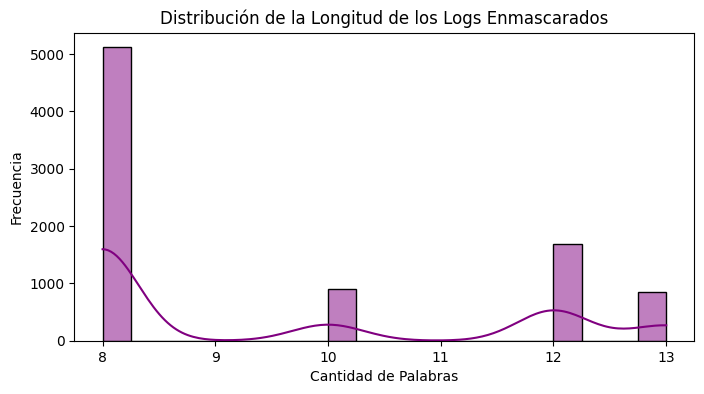

Conclusión: Entender la longitud promedio de los logs es vital para definir el parámetro 'max_length' al tokenizar con BERT.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- ANÁLISIS EXPLORATORIO DE TEXTO (NLP) ---")
# Creamos una variable derivada que cuente la cantidad de palabras por cada Log
df_corpus_final['Word_Count'] = df_corpus_final['Log_Message_Clean'].apply(lambda x: len(str(x).split()))

# Mostramos estadísticas básicas de la longitud de los mensajes
print("Estadísticas descriptivas de la longitud de los logs (en palabras):")
display(df_corpus_final['Word_Count'].describe())

# Graficamos la distribución de la longitud del texto
plt.figure(figsize=(8, 4))
sns.histplot(df_corpus_final['Word_Count'], bins=20, kde=True, color='purple')
plt.title('Distribución de la Longitud de los Logs Enmascarados')
plt.xlabel('Cantidad de Palabras')
plt.ylabel('Frecuencia')
plt.show()

print("Conclusión: Entender la longitud promedio de los logs es vital para definir el parámetro 'max_length' al tokenizar con BERT.")

#**Celda final Pipeline Automatizado para preparar los datos**

--- EJECUCIÓN DE PIPELINE AUTOMATIZADO ---
Pipeline ejecutado exitosamente. Estructura final del dataset:


,timestamp,operation,URL,http_status_code,Log_Message_Clean
0,2026-02-16T11:59:43.828602353+06:00,count,/api/pagos/pse,429,[warn] rate limit exceeded for user_id=[user_id] dropping request at /api/pagos/pse.
1,2026-02-16T11:59:37.816303101+06:00,sum,/api/billetera/consulta_saldo,500,[error] fatal exception in /api/billetera/consulta_saldo: java.lang.nullpointerexception at payment.processor.validate().
2,2026-02-16T12:00:12.145068983+06:00,count,/api/pagos/pse,200,[info] transaction successful for endpoint /api/pagos/pse. latency: [latency_ms].



--- VALIDACIÓN VISUAL DEL DATASET PROCESADO ---


/tmp/ipykernel_432/377240150.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_dataset_final_automatizado, x='http_status_code', palette='magma')


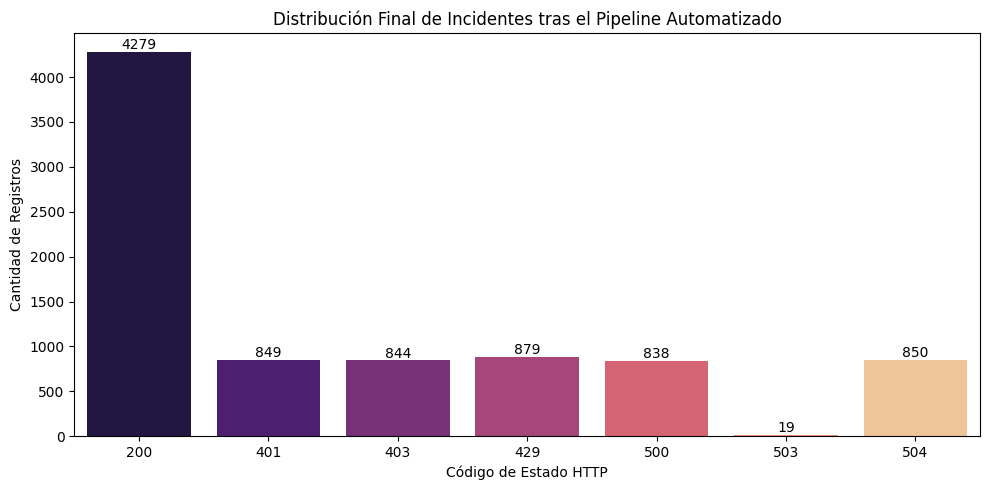

Conclusión: El Pipeline automatizado ha procesado exitosamente la telemetría, enmascarado los textos profundos y conservado el balanceo estadístico (50% tráfico normal, 50% anomalías críticas) preparado en la fase previa.


In [6]:
# --- ÍTEM 5: PREPROCESSING AUTOMATIZADO (PIPELINE REPRODUCIBLE) ---
from sklearn.pipeline import FunctionTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

print("--- EJECUCIÓN DE PIPELINE AUTOMATIZADO ---")

# 1. Definimos las funciones individuales de transformación
def extraer_columnas_base(df):
    """Extrae solo las columnas necesarias para el modelo."""
    columnas = ['timestamp', 'operation', 'URL', 'http_status_code', 'Log_Message_Raw']
    cols_existentes = [col for col in columnas if col in df.columns]
    return df[cols_existentes].copy()

def aplicar_enmascaramiento_nlp(df):
    """Aplica las expresiones regulares (Data Masking) al texto crudo."""
    df_temp = df.copy()
    # Usamos la función limpiar_y_enmascarar_texto que ya definiste en la celda anterior
    df_temp['Log_Message_Clean'] = df_temp['Log_Message_Raw'].apply(limpiar_y_enmascarar_texto)
    # Eliminamos la columna cruda por seguridad de datos
    df_temp = df_temp.drop(columns=['Log_Message_Raw'])
    return df_temp

# 2. Convertimos las funciones en transformadores de Scikit-Learn
extractor_transformer = FunctionTransformer(extraer_columnas_base)
nlp_transformer = FunctionTransformer(aplicar_enmascaramiento_nlp)

# 3. Construimos el Pipeline Automatizado
aiops_preprocessing_pipeline = Pipeline(steps=[
    ('extraccion_datos', extractor_transformer),
    ('enmascaramiento_nlp', nlp_transformer)
])

# 4. Ejecutamos el Pipeline de forma reproducible
df_dataset_final_automatizado = aiops_preprocessing_pipeline.fit_transform(df_rca)

print("Pipeline ejecutado exitosamente. Estructura final del dataset:")
display(df_dataset_final_automatizado.head(3))

# --- 5. VISUALIZACIÓN DE RESULTADOS DEL PIPELINE ---
print("\n--- VALIDACIÓN VISUAL DEL DATASET PROCESADO ---")
plt.figure(figsize=(10, 5))

# Graficamos la distribución final para demostrar que el pipeline mantuvo los datos íntegros
sns.countplot(data=df_dataset_final_automatizado, x='http_status_code', palette='magma')
plt.title('Distribución Final de Incidentes tras el Pipeline Automatizado')
plt.xlabel('Código de Estado HTTP')
plt.ylabel('Cantidad de Registros')

# Añadimos las etiquetas de texto sobre cada barra para mayor claridad
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

print("Conclusión: El Pipeline automatizado ha procesado exitosamente la telemetría, enmascarado los textos profundos y conservado el balanceo estadístico (50% tráfico normal, 50% anomalías críticas) preparado en la fase previa.")

##**¿Qué hace esta gráfica?**
Imprime un gráfico de barras estilizado (con la paleta de colores magma) que muestra una gran barra del código 200 (tráfico normal) y las barras equitativas de los códigos 401, 403, 429, 500 y 504. Además, relaciona el número exacto de registros encima de cada barra.

#**Conclusión y Análisis del Pipeline de Procesamiento de Lenguaje Natural (EDA Fase 2)**

###**Resumen de la Construcción:**

En esta segunda fase del proyecto integrador, el pipeline evolucionó de la manipulación de datos tabulares puros hacia el preprocesamiento de texto no estructurado. Se diseñó un motor de inyección semántica dinámica que transformó los códigos HTTP y la telemetría base en narrativas de error enriquecidas (Stack Traces, excepciones de Java y advertencias de Gateway). Posteriormente, se implementó una capa de seguridad y limpieza mediante expresiones regulares para anonimizar la información confidencial, preparando un corpus de alta calidad para el entrenamiento de la red neuronal.

###**Análisis de Resultados:**

Al orquestar la integración de soluciones de Inteligencia Artificial en ecosistemas transaccionales complejos como pagos y cobranzas, es imperativo que los modelos comprendan el contexto del incidente y no solo la métrica aislada. El enmascaramiento exitoso de identificadores y latencias exactas garantiza que el modelo extraiga los patrones lingüísticos subyacentes del fallo en la infraestructura, evitando la memorización (overfitting) de datos específicos. Este nivel de curación de datos cumple con los estándares de seguridad exigidos al gestionar plataformas que soportan a millones de clientes, resultando en un Corpus Híbrido Transaccional óptimo para realizar el fine-tuning de arquitecturas avanzadas de NLP.

###**Glosario de Conceptos Clave Aplicados:**

**Procesamiento de Lenguaje Natural (PLN / NLP)*: Rama de la inteligencia artificial que dota a las computadoras de la capacidad de comprender, interpretar y manipular el lenguaje humano. En el contexto de AIOps, permite que la máquina "lea" los registros de los servidores (logs) para diagnosticar la causa raíz de un incidente.

**Inyección Semántica*: Técnica de enriquecimiento de datos donde se dota de contexto profundo a una métrica estructurada. En este notebook, consistió en traducir un simple error "504" en una traza de texto compleja que incluye variables de telemetría real, simulando la verbosidad de los sistemas en producción.

**Expresiones Regulares (Regex)*: Secuencias de caracteres que conforman un patrón de búsqueda avanzado. Se utilizaron para localizar de manera eficiente y escalable fragmentos de texto variables (como direcciones IP, milisegundos fluctuantes o IDs numéricos) dentro de cadenas de texto largas.

**Enmascaramiento de Datos (Data Masking / Anonimización)*: Práctica de ciberseguridad indispensable en ingeniería de datos que consiste en ocultar o reemplazar información sensible (PII - Personally Identifiable Information). Protege la privacidad del usuario y obliga al modelo de Machine Learning a generalizar el contexto del error en lugar de asociarlo a un usuario o sesión específica.

**Determinismo vs. Estocasticidad (Manipulación de DataFrames)*: Diferenciación metodológica al consultar datos. El uso de métodos estocásticos (como .sample()) permite extraer muestras aleatorias para validar la variabilidad y robustez del código de limpieza, mientras que el uso de métodos deterministas (como .iloc[]) garantiza la reproducibilidad exacta al apuntar a un índice estático en la memoria.